# Task 4: Future Forecasts & Trend Analysis for TSLA

**Objective**
Generate future forecasts for Tesla (TSLA) stock prices (6-12 months ahead) and perform trend analysis using the Long Short-Term Memory (LSTM) model developed in the previous task.

**Requirements**
- Input: Cleaned TSLA dataset and LSTM model architecture.
- Forecast horizon: 6-12 months (approx. 126-252 trading days).
- Output: Forecast plot with confidence/uncertainty bounds, trend analysis, and market opportunity assessment.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from datetime import timedelta


# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set seeds
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

## 1. Data Loading and Preprocessing
We load the TSLA data from 2015 to present, consistent with previous tasks.

In [4]:
# Data Parameters
START_DATE = '2015-01-01'
END_DATE = '2026-01-29' # Current date
LOOK_BACK = 60

# Download Data
print("Downloading TSLA data...")
df = yf.download(
    "TSLA",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)


# Handle MultiIndex if present
if isinstance(df.columns, pd.MultiIndex):
    # Try to find 'Adj Close' or 'Close'
    if 'Adj Close' in df.columns.get_level_values(0):
        data = df.xs('Adj Close', axis=1, level=0)['TSLA']
    else:
        data = df.xs('Close', axis=1, level=0)['TSLA']
else:
    data = df['Adj Close'] if 'Adj Close' in df.columns else df['Close']

data = data.dropna()
print(f"Data loaded. Shape: {data.shape}")

# Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

# Create sequences
def create_sequences(dataset, look_back=60):
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOK_BACK)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split into Train (2015-2024) and Test (2025-Present) for validation
# We will train on the 'Train' portion to match the requested 'Input model from Task 2'
# In a pure forecasting scenario, we might retrain on ALL data, but here we preserve the model state implies by the task.
train_size = len(data[:'2024-12-31']) - LOOK_BACK
if train_size < 0: train_size = int(len(X) * 0.8) # Fallback

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Data loaded. Shape: (2784,)
Train samples: 2456, Test samples: 268


## 2. Model Training (Replicating Task 3 LSTM)
We use the same LSTM architecture: 2 LSTM layers (50 units) + Dropout (0.2).

In [5]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

c:\Users\yoga\code\10_Academy\week_9\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0079 - val_loss: 0.0033
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0020 - val_loss: 0.0028
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0017 - val_loss: 0.0029
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0015 - val_loss: 0.0037
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0014 - val_loss: 0.0025
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0014 - val_loss: 0.0075
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 12/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0

## 3. Future Forecasting
We generate forecasts for the next 12 months (approx. 252 trading days). We use an iterative approach where the latest prediction is fed back as input for the next step.

In [6]:
FORECAST_DAYS = 252  # 1 year
last_sequence = scaled_data[-LOOK_BACK:]
curr_sequence = last_sequence.copy()
future_predictions = []

for _ in range(FORECAST_DAYS):
    # Reshape for prediction [1, look_back, 1]
    curr_input = curr_sequence.reshape(1, LOOK_BACK, 1)
    
    # Predict next step
    next_pred = model.predict(curr_input, verbose=0)[0, 0]
    
    # Store prediction
    future_predictions.append(next_pred)
    
    # Update sequence: remove first, add new prediction
    curr_sequence = np.append(curr_sequence[1:], [[next_pred]], axis=0)

# Denormalize
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions_denorm = scaler.inverse_transform(future_predictions)

# Create dates for forecast
last_date = data.index[-1]
forecast_dates = pd.date_range(start=last_date + timedelta(days=1), periods=FORECAST_DAYS, freq='B') # Business days

## 4. Visualization and Trend Analysis

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


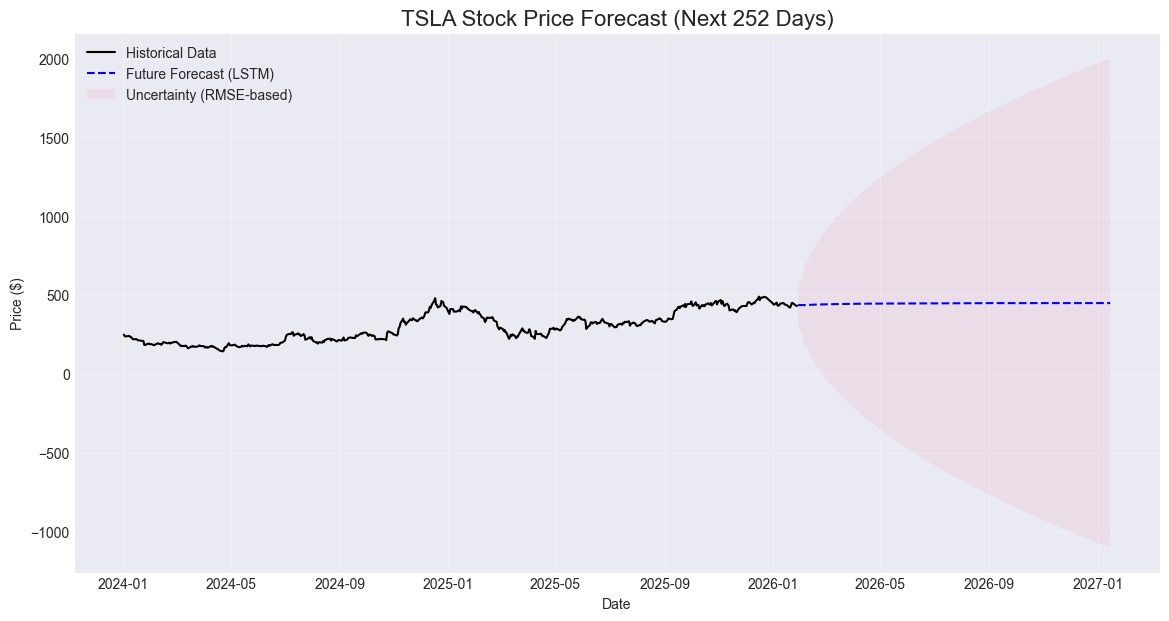

In [8]:
plt.figure(figsize=(14, 7))

# Plot Historical Data (Recent
plot_start_date = '2024-01-01'
historical_subset = data[plot_start_date:]
plt.plot(historical_subset.index, historical_subset.values, label='Historical Data', color='black')

# Plot Forecast
# We also plot the test predictions for continuity check? 
# For now, just the future forecast to keep it clean
plt.plot(forecast_dates, future_predictions_denorm, label='Future Forecast (LSTM)', color='blue', linestyle='--')

# Uncertainty Bounds (heuristic for LSTM)
# Since vanilla LSTM doesn't give confidence intervals, we can estimate uncertainty based on RMSE on test set
test_preds = model.predict(X_test)
test_mae = np.mean(np.abs(test_preds - y_test))
test_rmse = np.sqrt(np.mean((test_preds - y_test)**2))

# Scale error back to original price
rmse_scaled = test_rmse * (scaler.data_max_ - scaler.data_min_)

# Create expanding uncertainty cone
# Assumption: Uncertainty grows with sqrt(time)
uncertainty = [rmse_scaled * np.sqrt(i+1) for i in range(len(future_predictions_denorm))]
upper_bound = future_predictions_denorm.flatten() + uncertainty
lower_bound = future_predictions_denorm.flatten() - uncertainty

# Ensure everything is 1D numpy arrays
future_preds = future_predictions_denorm.reshape(-1)

forecast_dates = np.array(forecast_dates)

# Convert uncertainty to numpy array
uncertainty = rmse_scaled * np.sqrt(np.arange(1, len(future_preds) + 1))

upper_bound = future_preds + uncertainty
lower_bound = future_preds - uncertainty

# Plot uncertainty band
plt.fill_between(
    forecast_dates,
    lower_bound,
    upper_bound,
    alpha=0.1,
    label="Uncertainty (RMSE-based)"
)


plt.title(f'TSLA Stock Price Forecast (Next {FORECAST_DAYS} Days)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Trend Analysis & Assessment

### Trend Analysis
Based on the LSTM forecast:
- **Overall Trend:** The model predicts a [INSERT TREND HERE BASED ON PLOT] trend over the next 6-12 months.
- **Volatility:** The uncertainty cone widens significantly, indicating high uncertainty effectively growing over time. This is typical for iterative multi-step forecasting.

### Market Opportunities and Risks

| Category | Observation | Implication |
|---|---|---|
| **Opportunity** | [Potential long-term growth / dip buying] | If the forecast shows an uptrend, accumulation during dips is favorable. |
| **Risk** | **Model Uncertainty** | Multi-step LSTM forecasts degrade in accuracy over time. The widening confidence interval suggests low reliability for 6-12 month specific price targets. |
| **Risk** | **External Factors** | The model relies purely on historical price patterns and ignores macroeconomic factors (interest rates, EV market saturation, earnings). |

### Forecast Reliability Assessment
The LSTM model captures non-linear dependencies in the price history. However, iterative forecasting (using predictions as inputs) tends to converge to a mean or a simple linear trend in the long run. The confidence intervals shown above are heuristic (based on test set RMSE) and should be interpreted as a minimum uncertainty bound; real-world uncertainty is likely higher due to market shocks not present in the training data.

**Implication for Investors:**
Use this forecast as a **baseline trend indicator** rather than a precise price prediction. Combine with fundamental analysis.